In [1]:
import sympy as sp
import sympy.physics.mechanics as me
from sympy.vector import CoordSys3D, dot, cross
sp.init_printing()

## Definitions
Define the coordinate system $N$ and $x$ and $y$ component symbols for all necessary vectors

In [2]:
N = CoordSys3D('N')
#components
vsx, vsy = sp.symbols('v_{sx} v_{sy}', real=True)
vlx, vly = sp.symbols('v_{lx} v_{ly}', real=True)
vnx, vny = sp.symbols('v_{nx} v_{ny}', real=True)
#helium variables
rhos, rhon, rho = sp.symbols('rho_s rho_n rho', real=True)
kappa = sp.symbols('kappa', real=True)
gamma, gammap, beta, betap = sp.symbols(r"gamma gamma_1 beta beta_1", real=True)

#vortex tangent (unit vector along +z)
s = N.k

#superfluid velocity, vortex velocity and normal fluid velocity
vs = vsx*N.i + vsy*N.j
vl = vlx*N.i + vly*N.j
vn = vnx*N.i + vny*N.j

## Find the drag force
Assuming no mutual friction, the vortex velocity is (see associated paper for derivation)
$\newcommand{\bv}{\mathbf{v}}$
$$ \bv_L = \left(1 - \beta^2\right)\left[\bv_s - \mathbf{s}\times\bv_s\beta\left(1 - \beta^2\right)^{-1/2} \right], $$
where $\beta = v_{pin}/v_{s}$

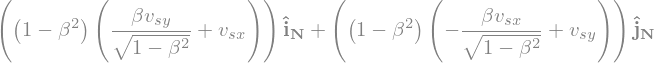

In [4]:
vl_nomf = (1 - beta**2)*(vs - cross(s, vs)*beta*1/sp.sqrt(1 - beta**2))
vl_nomf

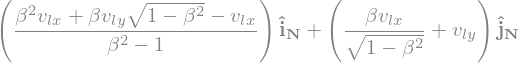

In [5]:
# Express the superfluid velocity in terms of the vortex velocity
sol = sp.solve([dot(vl_nomf - vl, N.i), dot(vl_nomf - vl, N.j)], (vsx, vsy))
vs_vl = sol[vsx].simplify()*N.i + sol[vsy].simplify()*N.j
vs_vl

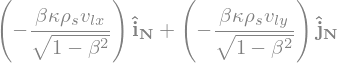

In [6]:
#assuming no mutual friction, drag force must be equal to the magnus force with the vortex velocity above
F_magnus = rhos*kappa*cross(s, vl - vs)

F_drag = -F_magnus.subs(vsx, dot(vs_vl, N.i)).subs(vsy, dot(vs_vl, N.j)).simplify()

F_drag

i.e., the drag force due to pinning is 

$$ \mathbf{F}_{drag} = -\kappa\rho_s\frac{\beta}{\sqrt{1 - \beta^2}}\bv_L = -\kappa\rho_s\Gamma \bv_L, $$

where we defined $\Gamma = \beta/\sqrt{1 - \beta^2}$. The equation of motion of the vortex with mutual friction included is thus

$$ \rho_s\kappa \mathbf{s'}\times (\bv_L - \bv_s) -\rho_s\kappa\Gamma \bv_L + \gamma(\bv_n - \bv_L) + \gamma_1\mathbf{s'}\times(\bv_n - \bv_s) = 0$$

which shows that the effect of drag due to pinning, for $v_s > v_{pin}$ is to reduce the mutual firction coefficient $\gamma \to \gamma - \rho_s\kappa\Gamma$. The remaining task is to calculate the modified mutual frcition coefficients $\alpha$ and $\alpha'$

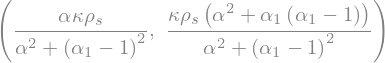

In [7]:
B, Bp = sp.symbols('B B_1', real=True)
alpha, alphap = sp.symbols('alpha alpha_1', real=True)

#relationship between gamma and B [Barenghi, Donnelly, Vinen, Friction on quantized vortices in Helium II. A Review]
gamma_sub = rhon*rhos/(2*rho)*kappa*B/((1 - Bp*rhon/2/rho)**2 + B**2*rhon**2/4/rho**2)
gammap_sub = rhon*rhos/(2*rho)*kappa*(B**2*rhon/2/rho - Bp*(1 - Bp*rhon/2/rho))/((1 - Bp*rhon/2/rho)**2 + B**2*rhon**2/4/rho**2)

#relationship between B and alpha
gamma_sub = gamma_sub.subs(B, 2*rho*alpha/rhon).subs(Bp, 2*rho*alphap/rhon).simplify()
gammap_sub = gammap_sub.subs(B, 2*rho*alpha/rhon).subs(Bp, 2*rho*alphap/rhon).simplify()

#finall gamma expressed through alpha
gamma_sub, gammap_sub

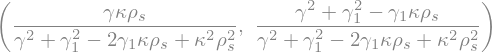

In [8]:
Gamma = sp.symbols('Gamma', real=True) # the drag coefficient

#invert the alpha/gamma relationship to express alpha in terms of gamma
sol = sp.solve([gamma_sub - gamma, gammap_sub - gammap], (alpha, alphap))
sol[0]

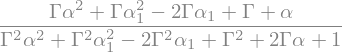

In [9]:
#substitute the shifted gamma and then again express the unperturbed gammas using the unperturbed alphas

#modified alpha
alpha_hat = sol[0][0].subs(gamma, gamma + rhos*kappa*Gamma).subs(gamma, gamma_sub).subs(gammap, gammap_sub).simplify()
alpha_hat

In [10]:
#sanity check
sp.limit((alpha_hat).simplify(), Gamma, sp.oo, dir='-')

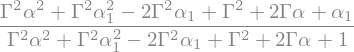

In [11]:
#modified alpha'
alphap_hat = sol[0][1].subs(gamma, gamma + rhos*kappa*Gamma).subs(gamma, gamma_sub).subs(gammap, gammap_sub).simplify()
alphap_hat

In [12]:
#sanity check, should be 1 so that v_L continuously increases above 0
sp.limit(alphap_hat, Gamma, sp.oo, dir='-').simplify()

In [13]:
sp.series(alpha_hat, Gamma, n=2).simplify()

In [14]:
#latex printing for the paper
print(sp.latex(alpha_hat).replace('_{1}', "'"))

\frac{\Gamma \alpha^{2} + \Gamma \alpha'^{2} - 2 \Gamma \alpha' + \Gamma + \alpha}{\Gamma^{2} \alpha^{2} + \Gamma^{2} \alpha'^{2} - 2 \Gamma^{2} \alpha' + \Gamma^{2} + 2 \Gamma \alpha + 1}


In [15]:
#latex printing for the paper
print(sp.latex(alphap_hat).replace('_{1}', "'"))

\frac{\Gamma^{2} \alpha^{2} + \Gamma^{2} \alpha'^{2} - 2 \Gamma^{2} \alpha' + \Gamma^{2} + 2 \Gamma \alpha + \alpha'}{\Gamma^{2} \alpha^{2} + \Gamma^{2} \alpha'^{2} - 2 \Gamma^{2} \alpha' + \Gamma^{2} + 2 \Gamma \alpha + 1}


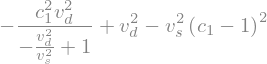

In [16]:
#double check the solution to (7)
vs, c1, vd = sp.symbols('v_s c_1 v_d', real=True)
eq = vd**2 - (c1 - 1)**2*vs**2 - c1**2*vd**2/vs**2*1/(1 - vd**2/vs**2)*vs**2
eq

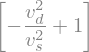

In [17]:
sp.solve(eq, c1)